In [3]:
!pip install emoji
!pip install nltk
!pip install scikit-learn
!pip install xgboost
!pip install transformers
!pip install torch
!pip install datasets
!pip install evaluate
!pip install indic-nlp-library


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 13.4 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import re
import emoji
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
from nltk.corpus import stopwords
nltk.download('stopwords')

from sklearn.feature_extraction.text import TfidfVectorizer

import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
train_data = pd.read_csv('/content/AWM_train.csv')
validation_data = pd.read_csv('/content/AWM_dev.csv')
test_data = pd.read_csv('/content/AWM_test_without_labels.csv')

In [7]:
train_data.head()

,Text,Class
0,നവ്യയുടെ കയ്യിന്ന് കിട്ടിയതാണല്ലോ. ഇവൾക്ക് അതൊ...,Abusive
1,"""ഇവരുടെ പ്രശ്നം അസൂയ ആണ്, സുന്ദരികൾ ആയ നടിമാരോ...",Abusive
2,ചുമ്മാതല്ല ഇവളെ പണ്ട് ലവർ അലക്കി വിട്ടത്...വായ...,Abusive
3,"""ഒരു സിനിമയിൽ ജഗതി മദാമ്മയായിട്ട് വരുന്നുണ്ടല്...",Non-Abusive
4,ഈ വർഷത്തെ ബൂലോക തോൽവി പരാജയം അതിനുള്ള ഓസ്‌ക്കാ...,Abusive


In [8]:
train_data.shape

(2933, 2)

In [9]:
unique_labels = train_data['Class'].unique()
print(unique_labels)

['Abusive' 'Non-Abusive']


In [10]:
label_counts = train_data['Class'].value_counts()
print(label_counts)

Class
Abusive        1531
Non-Abusive    1402
Name: count, dtype: int64


In [11]:
train_data = train_data[train_data['Class'] != 'abusive']

In [12]:
label_counts = train_data['Class'].value_counts()
print(label_counts)

Class
Abusive        1531
Non-Abusive    1402
Name: count, dtype: int64


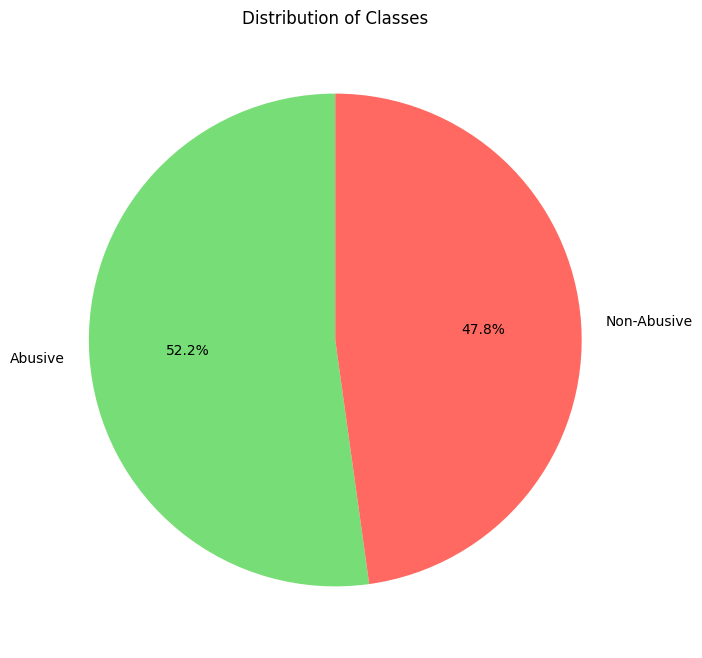

In [13]:
colors = ['#77DD77', '#FF6961']

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)

ax.set_title('Distribution of Classes')
plt.show()

In [15]:
stop_word_file_path = '/content/Malayalamstoppingwords.txt'

with open(stop_word_file_path, 'r') as file:
      stop_words_list = [line.strip() for line in file]

print(stop_words_list)

stop_words_list.append(stopwords.words('english'))

print(stop_words_list)

['ഒരു', 'അത്', 'ഇത്', 'അവൻ', 'അവൾ', 'അതു', 'എന്ത്', 'ആണ്', 'എന്ന്', 'ഉം', 'ഒന്ന്', 'എല്ലാ', 'പോലെ', 'ഇല്ല', 'നീ', 'ഞാൻ', 'നിങ്ങൾ', 'അവർ', 'ഇവിടെ', 'അവിടെ', 'എങ്ങനെ', 'എപ്പോൾ', 'എവിടെ', 'എന്തു', 'ചില', 'മറ്റു', 'തന്നെ', 'കൂടെ', 'വേണ്ടി', 'മാത്രം', 'വളരെ', 'കൂടുതൽ', 'കുറച്ച്', 'പിന്നെ', 'ഇപ്പോൾ', 'എന്നാൽ', 'അല്ലെങ്കിൽ', 'അതിനാൽ', 'എങ്കിലും', 'എങ്കിൽ', 'ആയ', 'ആയി', 'ഉള്ള', 'ഇല്ലാതെ', 'കൊണ്ട്', 'നിന്ന്', 'മുതൽ', 'വരെ', 'വേണം', 'ഉണ്ട്', 'ഉണ്ടായിരുന്നു', 'ചെയ്തു', 'ചെയ്യുന്നു', 'ചെയ്യും', 'ആകുന്നു', 'ആയിരിക്കും', 'തുടങ്ങി', 'കഴിഞ്ഞു', 'പോയി', 'വന്നു', 'കാണും', 'കാണുന്നു', 'കണ്ടു', 'തന്നെയാണ്', 'ആകട്ടെ']
['ഒരു', 'അത്', 'ഇത്', 'അവൻ', 'അവൾ', 'അതു', 'എന്ത്', 'ആണ്', 'എന്ന്', 'ഉം', 'ഒന്ന്', 'എല്ലാ', 'പോലെ', 'ഇല്ല', 'നീ', 'ഞാൻ', 'നിങ്ങൾ', 'അവർ', 'ഇവിടെ', 'അവിടെ', 'എങ്ങനെ', 'എപ്പോൾ', 'എവിടെ', 'എന്തു', 'ചില', 'മറ്റു', 'തന്നെ', 'കൂടെ', 'വേണ്ടി', 'മാത്രം', 'വളരെ', 'കൂടുതൽ', 'കുറച്ച്', 'പിന്നെ', 'ഇപ്പോൾ', 'എന്നാൽ', 'അല്ലെങ്കിൽ', 'അതിനാൽ', 'എങ്കിലും', 'എങ്കിൽ', 'ആയ', 'ആയി', 'ഉള്ള', 'ഇല്ലാതെ', 'കൊണ്ട്', '

In [16]:
import re
import emoji

def clean_malayalam_comments(comments):
    clean_comments = []

    # Correct Malayalam Unicode range (U+0D00 to U+0D7F)
    malayalam_unicode = r"\u0D00-\u0D7F"  # Includes all Malayalam characters

    for text in comments:
        # Remove URLs
        text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)

        # Remove email addresses
        text = re.sub(r"\S+@\S+\.\S+", "", text)

        # Remove emojis
        text = emoji.demojize(text, delimiters=(":", ":"))
        text = re.sub(r':\S+?:', '', text)

        # Convert English letters to lowercase
        text = re.sub(
            r"[A-Za-z]+",
            lambda match: match.group(0).lower(),
            text
        )

        # Allow Malayalam characters + basic punctuation
        text = re.sub(
            fr"[^{malayalam_unicode}\w\s.,!?\-%/'‘’“”()&]",
            "",
            text
        )

        # Remove numbers (Western and Malayalam numerals)
        text = re.sub(r"[\d+]|[\u0D66-\u0D6F]", "", text)

        # Normalize spaces and special characters
        text = re.sub(r"\s+", " ", text).strip()
        text = re.sub(r"\u200D", "", text)  # Remove ZWJ

        clean_comments.append(text)

    return clean_comments

In [17]:
def tokenize(comments):
    return [word_tokenize(comment) for comment in comments]

In [18]:
def remove_stop_words(comments):
  for words in comments:
    filtered_words = [word for word in words if word not in stop_words_list]
    words[:] = filtered_words
  return comments

In [19]:
def preprocess(comments):
  index = random.randint(0, len(comments) - 1)
  print("Original:", comments[index])

  comments = clean_malayalam_comments(comments)
  print("Cleaned:", comments[index])

  comments = tokenize(comments)
  print("Tokenised:", comments[index])

  comments = remove_stop_words(comments)
  print("After Stop Words Removal:", comments[index])

  return comments

In [20]:
train_data['clean_content'] = preprocess(train_data['Text'])

Original: ക്യാഷ് തിരിച്ചു കൊടുക്കാം എന്നുള്ള ക്ളീഷെ ഒന്നും വേണ്ട അത് ആർക്കും കിട്ടാനും പോവുന്നില്ല എന്ന് എല്ലാവർക്കും അറിയാം
Cleaned: ക്യാഷ് തിരിച്ചു കൊടുക്കാം എന്നുള്ള ക്ളീഷെ ഒന്നും വേണ്ട അത് ആർക്കും കിട്ടാനും പോവുന്നില്ല എന്ന് എല്ലാവർക്കും അറിയാം
Tokenised: ['ക്യാഷ്', 'തിരിച്ചു', 'കൊടുക്കാം', 'എന്നുള്ള', 'ക്ളീഷെ', 'ഒന്നും', 'വേണ്ട', 'അത്', 'ആർക്കും', 'കിട്ടാനും', 'പോവുന്നില്ല', 'എന്ന്', 'എല്ലാവർക്കും', 'അറിയാം']
After Stop Words Removal: ['ക്യാഷ്', 'തിരിച്ചു', 'കൊടുക്കാം', 'എന്നുള്ള', 'ക്ളീഷെ', 'ഒന്നും', 'വേണ്ട', 'ആർക്കും', 'കിട്ടാനും', 'പോവുന്നില്ല', 'എല്ലാവർക്കും', 'അറിയാം']


In [21]:
validation_data['clean_content'] = preprocess(validation_data['Text'])

Original: ദിൽഷയെ ഒരുപാടു ഇഷ്ട്ടമായിരുന്നു ഇപ്പോൾ അതിലേറെ വെറുക്കുന്നു
Cleaned: ദിൽഷയെ ഒരുപാടു ഇഷ്ട്ടമായിരുന്നു ഇപ്പോൾ അതിലേറെ വെറുക്കുന്നു
Tokenised: ['ദിൽഷയെ', 'ഒരുപാടു', 'ഇഷ്ട്ടമായിരുന്നു', 'ഇപ്പോൾ', 'അതിലേറെ', 'വെറുക്കുന്നു']
After Stop Words Removal: ['ദിൽഷയെ', 'ഒരുപാടു', 'ഇഷ്ട്ടമായിരുന്നു', 'അതിലേറെ', 'വെറുക്കുന്നു']


In [22]:
train_data.head()

,Text,Class,clean_content
0,നവ്യയുടെ കയ്യിന്ന് കിട്ടിയതാണല്ലോ. ഇവൾക്ക് അതൊ...,Abusive,"[നവ്യയുടെ, കയ്യിന്ന്, കിട്ടിയതാണല്ലോ, ., ഇവൾക്..."
1,"""ഇവരുടെ പ്രശ്നം അസൂയ ആണ്, സുന്ദരികൾ ആയ നടിമാരോ...",Abusive,"[ഇവരുടെ, പ്രശ്നം, അസൂയ, ,, സുന്ദരികൾ, നടിമാരോട..."
2,ചുമ്മാതല്ല ഇവളെ പണ്ട് ലവർ അലക്കി വിട്ടത്...വായ...,Abusive,"[ചുമ്മാതല്ല, ഇവളെ, പണ്ട്, ലവർ, അലക്കി, വിട്ടത്..."
3,"""ഒരു സിനിമയിൽ ജഗതി മദാമ്മയായിട്ട് വരുന്നുണ്ടല്...",Non-Abusive,"[സിനിമയിൽ, ജഗതി, മദാമ്മയായിട്ട്, വരുന്നുണ്ടല്ല..."
4,ഈ വർഷത്തെ ബൂലോക തോൽവി പരാജയം അതിനുള്ള ഓസ്‌ക്കാ...,Abusive,"[ഈ, വർഷത്തെ, ബൂലോക, തോൽവി, പരാജയം, അതിനുള്ള, ഓ..."


In [23]:
label_mapping = {label: idx for idx, label in enumerate(train_data['Class'].unique())}
train_data['numerical_labels'] = train_data['Class'].map(label_mapping)
validation_data['numerical_labels'] = validation_data['Class'].map(label_mapping)

In [24]:
train_data.head()

,Text,Class,clean_content,numerical_labels
0,നവ്യയുടെ കയ്യിന്ന് കിട്ടിയതാണല്ലോ. ഇവൾക്ക് അതൊ...,Abusive,"[നവ്യയുടെ, കയ്യിന്ന്, കിട്ടിയതാണല്ലോ, ., ഇവൾക്...",0
1,"""ഇവരുടെ പ്രശ്നം അസൂയ ആണ്, സുന്ദരികൾ ആയ നടിമാരോ...",Abusive,"[ഇവരുടെ, പ്രശ്നം, അസൂയ, ,, സുന്ദരികൾ, നടിമാരോട...",0
2,ചുമ്മാതല്ല ഇവളെ പണ്ട് ലവർ അലക്കി വിട്ടത്...വായ...,Abusive,"[ചുമ്മാതല്ല, ഇവളെ, പണ്ട്, ലവർ, അലക്കി, വിട്ടത്...",0
3,"""ഒരു സിനിമയിൽ ജഗതി മദാമ്മയായിട്ട് വരുന്നുണ്ടല്...",Non-Abusive,"[സിനിമയിൽ, ജഗതി, മദാമ്മയായിട്ട്, വരുന്നുണ്ടല്ല...",1
4,ഈ വർഷത്തെ ബൂലോക തോൽവി പരാജയം അതിനുള്ള ഓസ്‌ക്കാ...,Abusive,"[ഈ, വർഷത്തെ, ബൂലോക, തോൽവി, പരാജയം, അതിനുള്ള, ഓ...",0


In [25]:
X_train = [' '.join(comment) for comment in train_data['clean_content']]
y_train = train_data['numerical_labels']

In [26]:
X_val = [' '.join(comment) for comment in validation_data['clean_content']]
y_val = validation_data['numerical_labels']

In [27]:
print(set(y_train))
print(set(y_val))

{0, 1}
{0, 1}


In [28]:
!pip install --upgrade transformers

In [29]:
!pip install trl>=0.7.0 transformers>=4.31.0

In [54]:
# Step 1: Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("google/muril-base-cased")
model = AutoModelForSequenceClassification.from_pretrained("google/muril-base-cased", num_labels=2)

# Step 2: Preprocess the dataset
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# Convert your data into Hugging Face Dataset format
train_data = Dataset.from_dict({"text": X_train, "label": y_train})
val_data = Dataset.from_dict({"text": X_val, "label": y_val})

# Tokenize the datasets
train_data = train_data.map(preprocess_function, batched=True)
val_data = val_data.map(preprocess_function, batched=True)

# Set format for PyTorch
train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# Step 3: Define the metrics
def compute_metrics(pred):
    predictions = np.argmax(pred.predictions, axis=1)
    accuracy = accuracy_score(pred.label_ids, predictions)
    f1 = f1_score(pred.label_ids, predictions)
    precision = precision_score(pred.label_ids, predictions)
    recall = recall_score(pred.label_ids, predictions)
    return {"accuracy": accuracy, "f1": f1, "precision": precision, "recall": recall}

# Step 4: Training Arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    save_strategy="epoch",
    save_total_limit=2,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=42,
    report_to="none",
)

# Step 5: Define the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Step 6: Train the model
trainer.train()

# Step 7: Evaluate the model
results = trainer.evaluate()
print("Final Evaluation Results:", results)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/2933 [00:00<?, ? examples/s]

Map:   0%|          | 0/629 [00:00<?, ? examples/s]

<ipython-input-54-32d754da7089>:50: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.672200,0.666007,0.666137,0.588235,0.815217,0.460123
2,0.567700,0.588276,0.717011,0.743516,0.701087,0.791411
3,0.548700,0.576423,0.718601,0.744589,0.702997,0.791411
4,0.426300,0.597769,0.712242,0.754410,0.676399,0.852761
5,0.406000,0.601466,0.720191,0.759563,0.684729,0.852761


Final Evaluation Results: {'eval_loss': 0.6014658212661743, 'eval_accuracy': 0.7201907790143084, 'eval_f1': 0.7595628415300546, 'eval_precision': 0.6847290640394089, 'eval_recall': 0.852760736196319, 'eval_runtime': 4.7806, 'eval_samples_per_second': 131.575, 'eval_steps_per_second': 8.367, 'epoch': 5.0}


In [55]:
# Save the model and tokenizer
model.save_pretrained("/content/drive/MyDrive/Women Abuse/saved_model")
tokenizer.save_pretrained("/content/drive/MyDrive/Women Abuse/saved_model")

('/content/drive/MyDrive/Women Abuse/saved_model/tokenizer_config.json',
 '/content/drive/MyDrive/Women Abuse/saved_model/special_tokens_map.json',
 '/content/drive/MyDrive/Women Abuse/saved_model/vocab.txt',
 '/content/drive/MyDrive/Women Abuse/saved_model/added_tokens.json',
 '/content/drive/MyDrive/Women Abuse/saved_model/tokenizer.json')

In [56]:
# Load the saved model and tokenizer
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/Women Abuse/saved_model")
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/Women Abuse/saved_model")

# Prepare new Malayalam text data (actual abusive/non-abusive examples)
new_texts = [
    "നിന്റെ അമ്മയെ പോലെയുള്ളവർക്ക് വീട്ടിൽ തന്നെ നിൽക്കാൻ പാടില്ല",  # Likely abusive
]

# Tokenize with proper handling
encoded_inputs = tokenizer(
    new_texts,
    truncation=True,
    padding="max_length",
    max_length=128,
    return_tensors="pt"
)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
encoded_inputs = {k: v.to(device) for k, v in encoded_inputs.items()}

# Prediction with confidence scores
with torch.no_grad():
    outputs = model(**encoded_inputs)
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predictions = torch.argmax(outputs.logits, axis=1)

# Map predictions to labels (assuming 0=non-abusive, 1=abusive)
label_map = {0: "Non-Abusive", 1: "Abusive"}

print("\nMalayalam Abuse Detection Predictions:")
for text, pred, prob in zip(new_texts, predictions.cpu().numpy(), probabilities.cpu().numpy()):
    print(f"\nText: {text}")
    print(f"Prediction: {label_map[pred]} (Confidence: {prob[pred]:.2%})")
    print("Class Probabilities:")
    print(f"- Non-Abusive: {prob[0]:.2%}")
    print(f"- Abusive: {prob[1]:.2%}")
    print("─" * 50)


Malayalam Abuse Detection Predictions:

Text: നിന്റെ അമ്മയെ പോലെയുള്ളവർക്ക് വീട്ടിൽ തന്നെ നിൽക്കാൻ പാടില്ല
Prediction: Abusive (Confidence: 78.06%)
Class Probabilities:
- Non-Abusive: 21.94%
- Abusive: 78.06%
──────────────────────────────────────────────────


In [57]:
test_data.head()

,id,Text,clean_content,Predicted Class
0,1,സൂരജ് നിന്റെ ആര് ആണ് ആള് ഇറക്കി പേടിപ്പിക്കുക ആണോ,"[സൂരജ്, നിന്റെ, ആര്, ആള്, ഇറക്കി, പേടിപ്പിക്കു...",Abusive
1,2,എത്ര അലക്കി വെളുപ്പിച്ചാലും നിനക്കു അർഹത ഇല്ലാ...,"[എത്ര, അലക്കി, വെളുപ്പിച്ചാലും, നിനക്കു, അർഹത,...",Non-Abusive
2,3,50 ലക്ഷം കയ്യിൽ വയ്ക്കാൻ ഒരിക്കലും യോഗ്യത ഇല്ല...,"[ലക്ഷം, കയ്യിൽ, വയ്ക്കാൻ, ഒരിക്കലും, യോഗ്യത, റ...",Abusive
3,4,"""ബിഗ് ബോസ്സിൽ നിങ്ങളുടെ അഭിനയം എന്തായിരുന്നു,മ...","[ബിഗ്, ബോസ്സിൽ, നിങ്ങളുടെ, അഭിനയം, എന്തായിരുന്...",Non-Abusive
4,5,അത് അങ്ങനെയാ നമ്മുടെ ഉള്ളിൽ നന്മ ഉണ്ടെങ്കിൽ പട...,"[അങ്ങനെയാ, നമ്മുടെ, ഉള്ളിൽ, നന്മ, ഉണ്ടെങ്കിൽ, ...",Abusive


In [58]:
test_data['clean_content'] = preprocess(test_data['Text'])
X_test = [' '.join(comment) for comment in test_data['clean_content']]

Original: നിന്നെ ഇഷ്ടപ്പെടുന്ന കുറച്ചുപേർ അത്രയേ ഉള്ളു ആ കുറച്ചുപേർ വോട്ട് ചെയ്താൽ ദിൽഷ ജയിക്കില്ലായിരുന്നു
Cleaned: നിന്നെ ഇഷ്ടപ്പെടുന്ന കുറച്ചുപേർ അത്രയേ ഉള്ളു ആ കുറച്ചുപേർ വോട്ട് ചെയ്താൽ ദിൽഷ ജയിക്കില്ലായിരുന്നു
Tokenised: ['നിന്നെ', 'ഇഷ്ടപ്പെടുന്ന', 'കുറച്ചുപേർ', 'അത്രയേ', 'ഉള്ളു', 'ആ', 'കുറച്ചുപേർ', 'വോട്ട്', 'ചെയ്താൽ', 'ദിൽഷ', 'ജയിക്കില്ലായിരുന്നു']
After Stop Words Removal: ['നിന്നെ', 'ഇഷ്ടപ്പെടുന്ന', 'കുറച്ചുപേർ', 'അത്രയേ', 'ഉള്ളു', 'ആ', 'കുറച്ചുപേർ', 'വോട്ട്', 'ചെയ്താൽ', 'ദിൽഷ', 'ജയിക്കില്ലായിരുന്നു']


In [59]:
encoded_inputs = tokenizer(X_test, truncation=True, padding="max_length", max_length=128, return_tensors="pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
encoded_inputs = {key: val.to(device) for key, val in encoded_inputs.items()}

# Predict
with torch.no_grad():
    outputs = model(**encoded_inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, axis=1)

print("Predicted Labels:\n", predictions.cpu().numpy())

Predicted Labels:
 [1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 1 1 1 0 1
 1 1 1 0 1 0 0 0 0 1 1 0 0 1 0 0 1 0 1 1 1 1 1 1 1 0 0 1 0 0 0 0 1 0 0 0 0
 0 1 1 0 0 0 0 0 1 1 1 1 1 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 0 1 0 0 1 1
 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1
 1 1 0 1 1 0 1 1 1 1 1 1 0 1 0 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1
 0 0 1 1 0 1 1 1 0 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 1 0 1 1 1 1 1 0
 0 1 1 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1 1 1 1
 0 1 0 1 1 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 0 1 0 1 1
 1 0 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 1 0 1 1 1
 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 1 0 0
 1 1 0 1 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 0 1 0 0 1 0 0 1 1 0 1 1 1 1 0 1
 1 0 1 0 1 0 0 0 0 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 0 0 0 1 1 0 0 0 0 1
 1 0 0

In [39]:
mapping = {0: 'Non-Abusive', 1: 'Abusive'}
test_data['Predicted Class'] = predictions.cpu().numpy()
test_data['Predicted Class'] = test_data['Predicted Class'].map(mapping)

In [60]:
test_data.head()

,id,Text,clean_content,Predicted Class
0,1,സൂരജ് നിന്റെ ആര് ആണ് ആള് ഇറക്കി പേടിപ്പിക്കുക ആണോ,"[സൂരജ്, നിന്റെ, ആര്, ആള്, ഇറക്കി, പേടിപ്പിക്കു...",Abusive
1,2,എത്ര അലക്കി വെളുപ്പിച്ചാലും നിനക്കു അർഹത ഇല്ലാ...,"[എത്ര, അലക്കി, വെളുപ്പിച്ചാലും, നിനക്കു, അർഹത,...",Non-Abusive
2,3,50 ലക്ഷം കയ്യിൽ വയ്ക്കാൻ ഒരിക്കലും യോഗ്യത ഇല്ല...,"[ലക്ഷം, കയ്യിൽ, വയ്ക്കാൻ, ഒരിക്കലും, യോഗ്യത, റ...",Abusive
3,4,"""ബിഗ് ബോസ്സിൽ നിങ്ങളുടെ അഭിനയം എന്തായിരുന്നു,മ...","[ബിഗ്, ബോസ്സിൽ, നിങ്ങളുടെ, അഭിനയം, എന്തായിരുന്...",Non-Abusive
4,5,അത് അങ്ങനെയാ നമ്മുടെ ഉള്ളിൽ നന്മ ഉണ്ടെങ്കിൽ പട...,"[അങ്ങനെയാ, നമ്മുടെ, ഉള്ളിൽ, നന്മ, ഉണ്ടെങ്കിൽ, ...",Abusive


In [41]:
print_data = test_data[['Text', 'Predicted Class']]

In [61]:
print_data.head()

,Id,Labels
0,സൂരജ് നിന്റെ ആര് ആണ് ആള് ഇറക്കി പേടിപ്പിക്കുക ആണോ,Abusive
1,എത്ര അലക്കി വെളുപ്പിച്ചാലും നിനക്കു അർഹത ഇല്ലാ...,Non-Abusive
2,50 ലക്ഷം കയ്യിൽ വയ്ക്കാൻ ഒരിക്കലും യോഗ്യത ഇല്ല...,Abusive
3,"""ബിഗ് ബോസ്സിൽ നിങ്ങളുടെ അഭിനയം എന്തായിരുന്നു,മ...",Non-Abusive
4,അത് അങ്ങനെയാ നമ്മുടെ ഉള്ളിൽ നന്മ ഉണ്ടെങ്കിൽ പട...,Abusive


In [62]:
print_data = print_data.rename(columns={'Text': 'Id', 'Predicted Class': 'Labels'})
print_data.head()

,Id,Labels
0,സൂരജ് നിന്റെ ആര് ആണ് ആള് ഇറക്കി പേടിപ്പിക്കുക ആണോ,Abusive
1,എത്ര അലക്കി വെളുപ്പിച്ചാലും നിനക്കു അർഹത ഇല്ലാ...,Non-Abusive
2,50 ലക്ഷം കയ്യിൽ വയ്ക്കാൻ ഒരിക്കലും യോഗ്യത ഇല്ല...,Abusive
3,"""ബിഗ് ബോസ്സിൽ നിങ്ങളുടെ അഭിനയം എന്തായിരുന്നു,മ...",Non-Abusive
4,അത് അങ്ങനെയാ നമ്മുടെ ഉള്ളിൽ നന്മ ഉണ്ടെങ്കിൽ പട...,Abusive


In [63]:
print_data.to_csv('/content/drive/MyDrive/JAS_Malayalam.csv', index=False)

# Tried and Tested

In [64]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

In [65]:
print(X_train[0])
print(X_train_tfidf[0])

നവ്യയുടെ കയ്യിന്ന് കിട്ടിയതാണല്ലോ . ഇവൾക്ക് അതൊന്നും ഏറ്റില്ലേ
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8 stored elements and shape (1, 1963)>
  Coords	Values
  (0, 1064)	0.4288593975279839
  (0, 1342)	0.4007387094846484
  (0, 573)	0.30929357211249503
  (0, 1323)	0.24157584007466523
  (0, 867)	0.4162704867262095
  (0, 346)	0.3899420069265731
  (0, 109)	0.2168057679604278
  (0, 465)	0.35934116895857615


In [66]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(max_iter=1000,solver='saga')

log_reg_model.fit(X_train_tfidf, y_train)

y_pred = log_reg_model.predict(X_val_tfidf)

print("Classification Report:\n", classification_report(y_val, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.62      0.63       303
           1       0.66      0.68      0.67       326

    accuracy                           0.65       629
   macro avg       0.65      0.65      0.65       629
weighted avg       0.65      0.65      0.65       629



In [67]:
from sklearn.svm import SVC

svc_model = SVC()

svc_model.fit(X_train_tfidf, y_train)

y_pred = svc_model.predict(X_val_tfidf)

print("Classification Report:\n", classification_report(y_val, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.62      0.64       303
           1       0.66      0.69      0.68       326

    accuracy                           0.66       629
   macro avg       0.66      0.66      0.66       629
weighted avg       0.66      0.66      0.66       629



In [68]:
from sklearn.svm import LinearSVC

lsvc_model = LinearSVC(random_state=0)

lsvc_model.fit(X_train_tfidf, y_train)

y_pred = lsvc_model.predict(X_val_tfidf)

print("Classification Report:\n", classification_report(y_val, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.62      0.62       303
           1       0.65      0.64      0.64       326

    accuracy                           0.63       629
   macro avg       0.63      0.63      0.63       629
weighted avg       0.63      0.63      0.63       629



In [69]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_model = XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_tfidf, y_train)

y_pred = xgb_model.predict(X_val_tfidf)

print("Classification Report:\n", classification_report(y_val, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.61      0.60       303
           1       0.63      0.61      0.62       326

    accuracy                           0.61       629
   macro avg       0.61      0.61      0.61       629
weighted avg       0.61      0.61      0.61       629



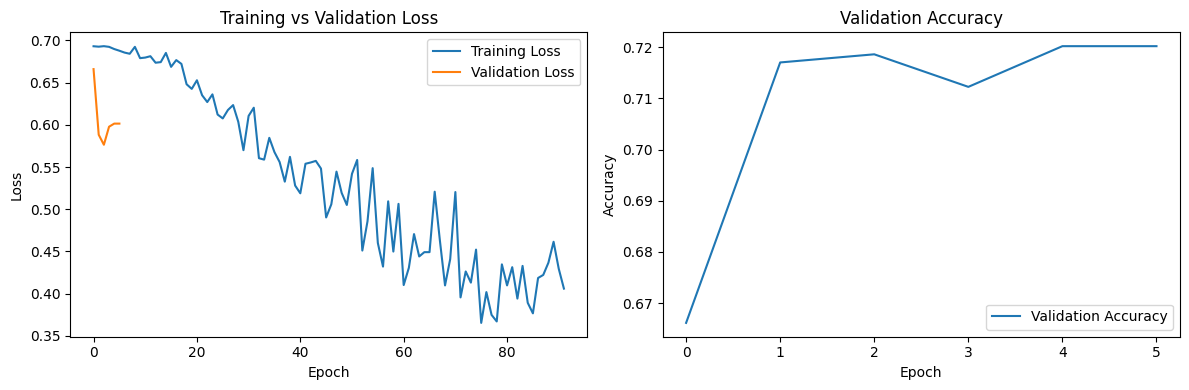

In [72]:
def plot_training_curves(trainer):
    log_history = trainer.state.log_history

    # Extract training loss and validation metrics
    train_loss = [entry['loss'] for entry in log_history if 'loss' in entry and 'eval_loss' not in entry]
    val_loss = [entry['eval_loss'] for entry in log_history if 'eval_loss' in entry]
    val_accuracy = [entry['eval_accuracy'] for entry in log_history if 'eval_accuracy' in entry]

    # Plot
    plt.figure(figsize=(12, 4))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy plot (validation only)
    plt.subplot(1, 2, 2)
    plt.plot(val_accuracy, label='Validation Accuracy')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function after training
plot_training_curves(trainer)  # Pass the trainer object instead of history

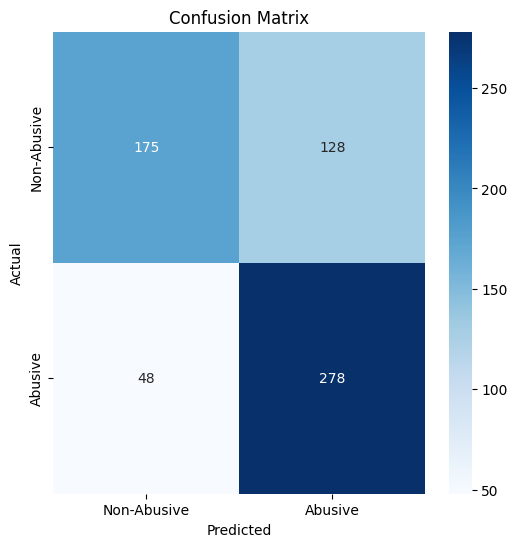

              precision    recall  f1-score   support

 Non-Abusive       0.78      0.58      0.67       303
     Abusive       0.68      0.85      0.76       326

    accuracy                           0.72       629
   macro avg       0.73      0.72      0.71       629
weighted avg       0.73      0.72      0.71       629



In [73]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions from the trained model
predictions = trainer.predict(val_data)  # Replace val_data with test_data if needed
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Abusive', 'Abusive'],
            yticklabels=['Non-Abusive', 'Abusive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print(classification_report(y_true, y_pred, target_names=['Non-Abusive', 'Abusive']))